# 1. Análise Exploratória

In [24]:
from matplotlib.artist import get
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import r2_score, mean_absolute_error

# Não limitar o tamanho da resposta
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

train_csv = pd.read_csv("data/train.csv")

## 1.1 Distribuição das Variáveis

### 1.1.1 Características das Variáveis
Ao analisar o dataframe gerado abaixo, vemos que os dados são bem diferentes, com vários dados cotendo nulls, outliers e categorias diferentes.

In [2]:
def get_outlier(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3-q1

    lim_sup = q3+(iqr*1.5)
    lim_inf = q1-(iqr*1.5)

    return series[(series < lim_inf) | (series > lim_sup)]

def set_outliers(series: pd.Series):
    if not pd.api.types.is_numeric_dtype(series.dtype):
        return "Não elegível"

    if get_outlier(series).any():
        return "Sim"
    return "Não"

exploracao_csv = pd.DataFrame(
    {
        "categoria": train_csv.dtypes.map(lambda x: "Numérico" if x.kind in "iufc" else "Categórico"),
        "tem_null": train_csv.isna().sum().map(lambda x: "Sim" if x >= 1 else "Não"),
        "tem_outliers": train_csv.apply(set_outliers)
    }
)

exploracao_csv.sort_values(by=["categoria", "tem_null", "tem_outliers"])

,categoria,tem_null,tem_outliers
MSZoning,Categórico,Não,Não elegível
Street,Categórico,Não,Não elegível
LotShape,Categórico,Não,Não elegível
LandContour,Categórico,Não,Não elegível
Utilities,Categórico,Não,Não elegível
LotConfig,Categórico,Não,Não elegível
LandSlope,Categórico,Não,Não elegível
Neighborhood,Categórico,Não,Não elegível
Condition1,Categórico,Não,Não elegível
Condition2,Categórico,Não,Não elegível


### 1.1.2 Distribuição do Preço de Venda das Propriedades
Observando o histograma com a linha de densidade (KDE), podemos destacar os seguintes pontos importantes:
1. **Assimetria Positiva:** A distribuição dos preços não é uma curva normal perfeita (simétrica). Ela possui uma assimetria à direita, formando uma "cauda longa" que se estende para os valores mais altos.
2. **Concentração de Valores:** A grande maioria dos imóveis é vendida por um preço entre **$100.000 e $200.000**. O pico principal do gráfico ocorre próximo aos $150.000.
3. **Presença de Outliers:** A cauda longa à direita deixa claro que existem propriedades com preços de venda muito acima da maioria, chegando a valores que ultrapassam a marca de **$700.000**. Embora sejam poucos imóveis (frequência baixa), eles impactam as métricas globais, puxando a média de preços para cima.

Isso implica que utilizar uma transformação matemática como a transformação logarítmica trará muitos benefícios nas etapas de machine learning.

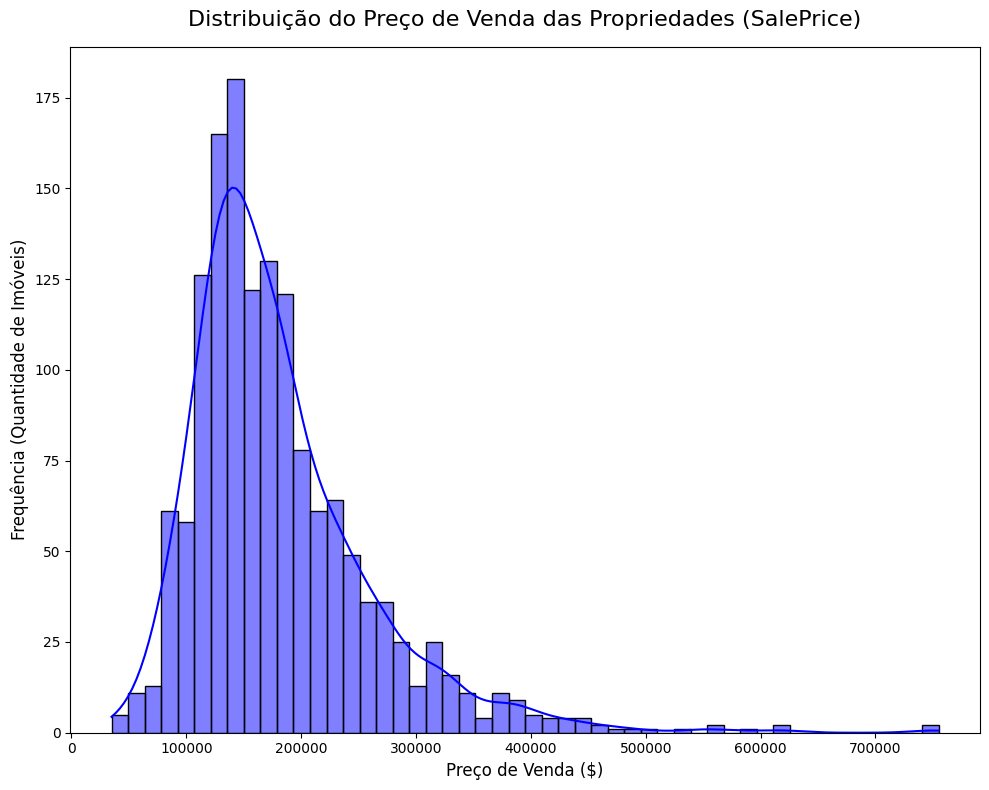

In [3]:
plt.figure(figsize=(10,8))
sb.histplot(
    train_csv["SalePrice"], kde=True, bins=50, color="blue"
)
plt.title("Distribuição do Preço de Venda das Propriedades (SalePrice)", fontsize=16, pad=15)
plt.xlabel("Preço de Venda ($)", fontsize=12)
plt.ylabel("Frequência (Quantidade de Imóveis)", fontsize=12)

plt.tight_layout()
plt.show()


## 1.2 Correlações e Dispersões

### 1.2.1 Gráfico de Correlação Geral
Olhando a matriz gerada abaixo, fica um pouco complicado analisar as correlações devido a grande quantidade de variáveis.

Então nós vamos utilizar outra forma...

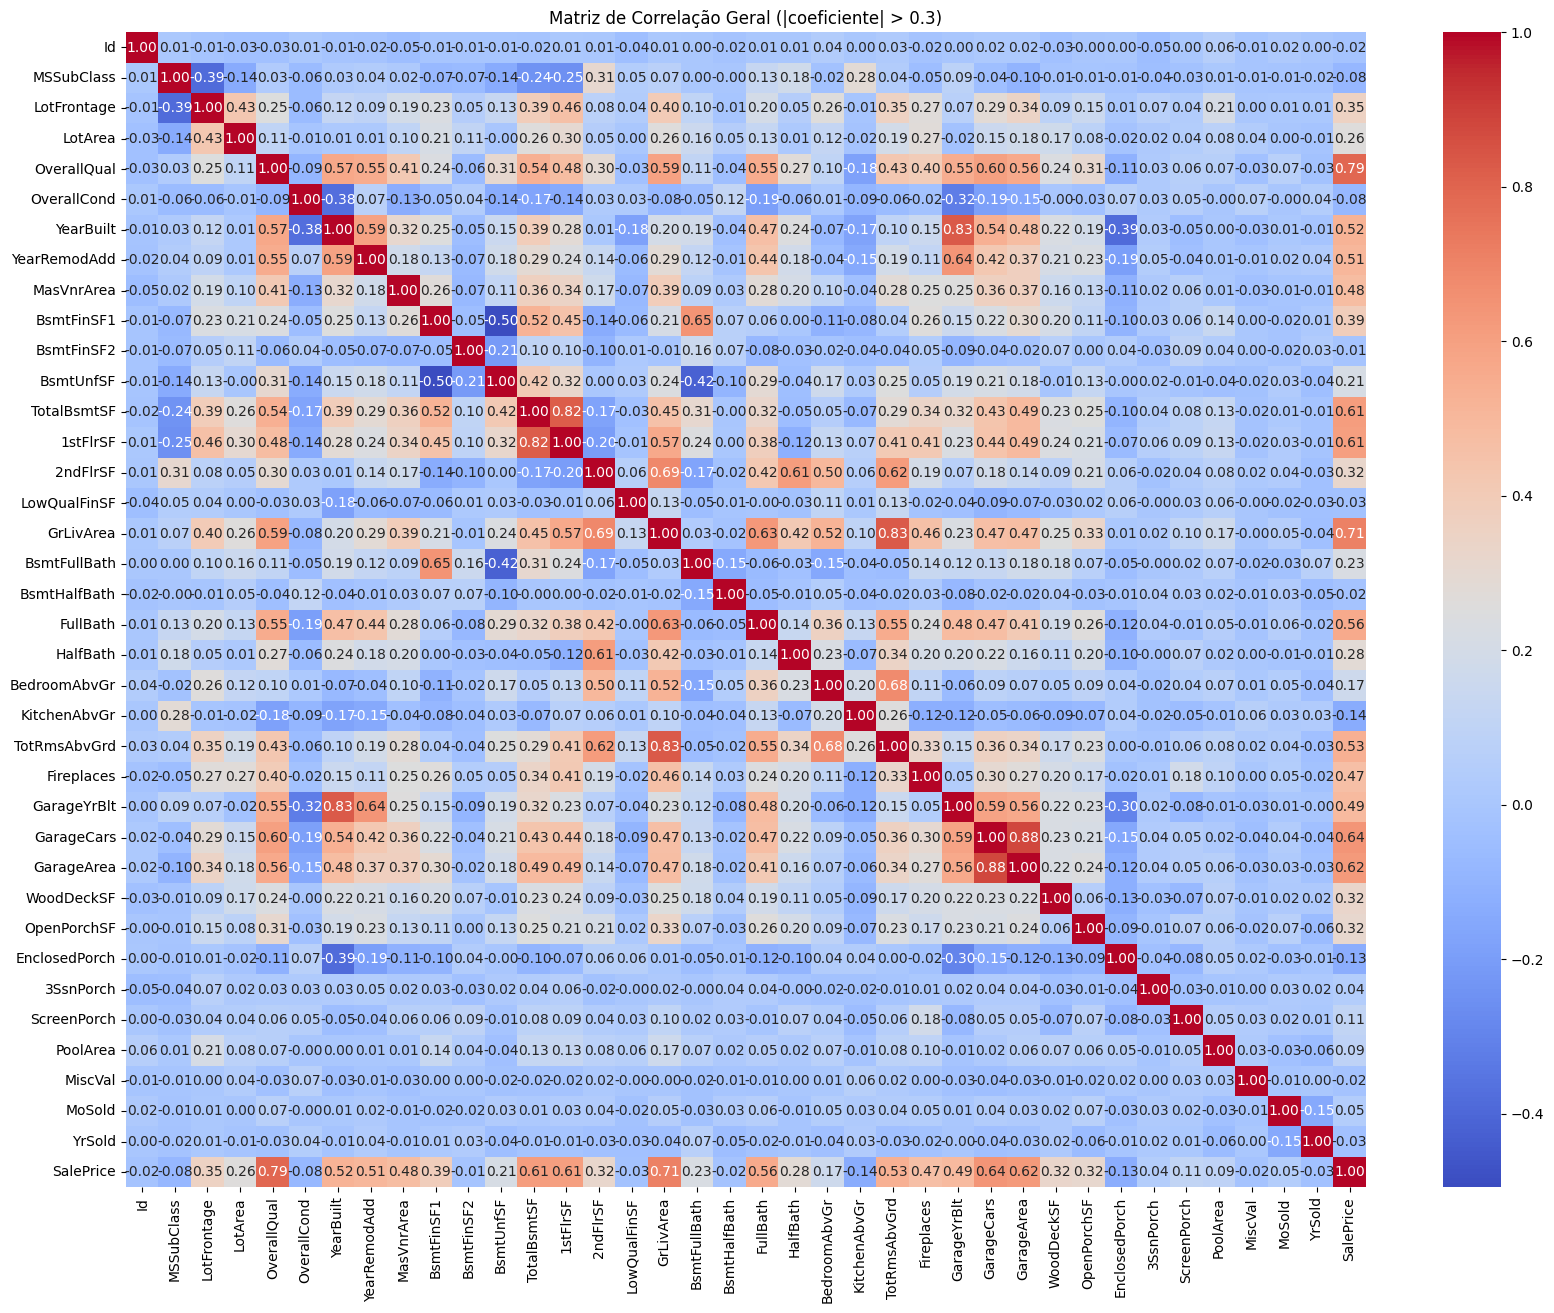

In [4]:
corr_matrix = train_csv.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação Geral (|coeficiente| > 0.3)")
plt.show()

### 1.2.1 Correlações com a variável de preço da propriedade (SalePrice)

Fizemos um filtro nos coeficientes de correlação absolutos das variáveis pegando somente as variáveis com um coeficiente relevante.

Assim a análise fica mais prática.

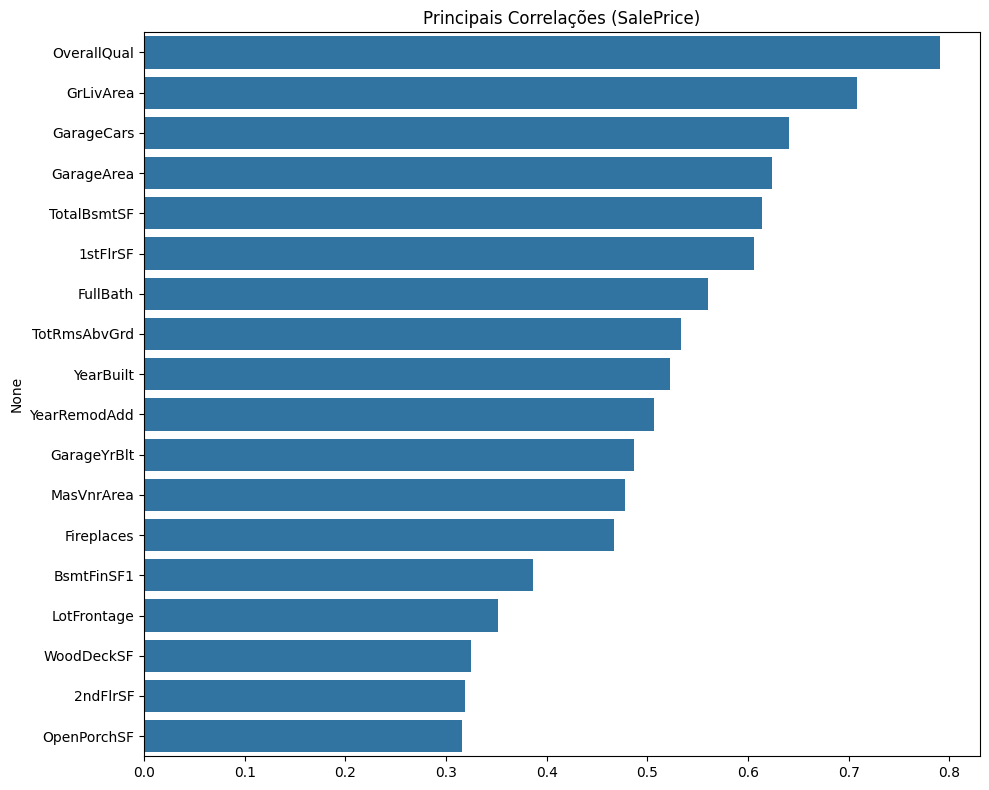

In [5]:
corr = train_csv.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).drop("SalePrice")

corr = corr.to_frame(name="correlation")
corr["abs_correlation"] = corr["correlation"].abs()

# Pega todas as variáveis com correlação absoluta maior ou igual que 0.3
best_corr = corr[corr["abs_correlation"] >= 0.3].sort_values(by="abs_correlation", ascending=False)

plt.figure(figsize=(10, 8))
sb.barplot(
    x=best_corr["correlation"].values,
    y=best_corr.index,
)
plt.title("Principais Correlações (SalePrice)")
plt.tight_layout()
plt.show()



### 1.2.2 Dispersão entre a área da propriedade e o preço (GrLivArea x SalePrice)
Aplicando um scatter plot na área habitável, vemos que quanto maior a área, maior o preço de venda.

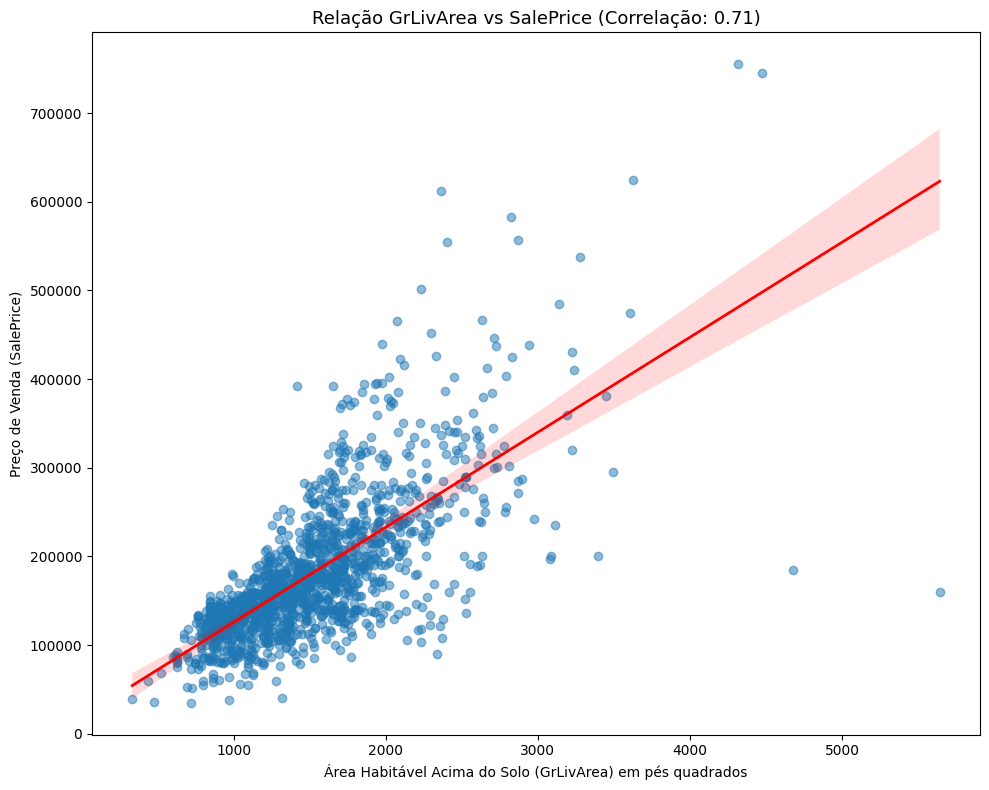

In [6]:
corr: pd.DataFrame = train_csv["GrLivArea"].corr(train_csv["SalePrice"])

plt.figure(figsize=(10,8))
sb.regplot(
    data=train_csv,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha":0.5, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title(f"Relação GrLivArea vs SalePrice (Correlação: {corr:.2f})", fontsize=13)
plt.xlabel("Área Habitável Acima do Solo (GrLivArea) em pés quadrados")
plt.ylabel("Preço de Venda (SalePrice)")
plt.tight_layout()
plt.show()

# 2 Feature Engineering

## 2.1 Renomeação de variáveis

In [7]:
dicionario_nomes = {
    'Id': 'Id',
    'MSSubClass': 'Classe_Imovel',
    'MSZoning': 'Zona_Classificacao',
    'LotFrontage': 'Fachada_Lote_Pes',
    'LotArea': 'Area_Lote_Pes2',
    'Street': 'Tipo_Rua',
    'Alley': 'Tipo_Beco',
    'LotShape': 'Formato_Lote',
    'LandContour': 'Contorno_Terreno',
    'Utilities': 'Utilidades_Disponiveis',
    'LotConfig': 'Configuracao_Lote',
    'LandSlope': 'Inclinacao_Terreno',
    'Neighborhood': 'Bairro',
    'Condition1': 'Proximidade_Condicao1',
    'Condition2': 'Proximidade_Condicao2',
    'BldgType': 'Tipo_Habitacao',
    'HouseStyle': 'Estilo_Habitacao',
    'OverallQual': 'Qualidade_Geral',
    'OverallCond': 'Condicao_Geral',
    'YearBuilt': 'Ano_Construcao',
    'YearRemodAdd': 'Ano_Reforma',
    'RoofStyle': 'Estilo_Telhado',
    'RoofMatl': 'Material_Telhado',
    'Exterior1st': 'Revestimento_Externo1',
    'Exterior2nd': 'Revestimento_Externo2',
    'MasVnrType': 'Tipo_Alvenaria',
    'MasVnrArea': 'Area_Alvenaria',
    'ExterQual': 'Qualidade_Externa',
    'ExterCond': 'Condicao_Externa',
    'Foundation': 'Tipo_Fundacao',
    'BsmtQual': 'Qualidade_Porao',
    'BsmtCond': 'Condicao_Porao',
    'BsmtExposure': 'Exposicao_Porao',
    'BsmtFinType1': 'Acabamento_Porao1',
    'BsmtFinSF1': 'Area_Acab_Porao1',
    'BsmtFinType2': 'Acabamento_Porao2',
    'BsmtFinSF2': 'Area_Acab_Porao2',
    'BsmtUnfSF': 'Area_Porao_Inacabado',
    'TotalBsmtSF': 'Area_Total_Porao',
    'Heating': 'Tipo_Aquecimento',
    'HeatingQC': 'Qualidade_Aquecimento',
    'CentralAir': 'Ar_Condicionado_Central',
    'Electrical': 'Sistema_Eletrico',
    '1stFlrSF': 'Area_Primeiro_Andar',
    '2ndFlrSF': 'Area_Segundo_Andar',
    'LowQualFinSF': 'Area_Baixa_Qualidade',
    'GrLivArea': 'Area_Habitavel_Acima_Solo',
    'BsmtFullBath': 'Banheiros_Completos_Porao',
    'BsmtHalfBath': 'Lavabos_Porao',
    'FullBath': 'Banheiros_Completos',
    'HalfBath': 'Lavabos',
    'BedroomAbvGr': 'Quartos_Acima_Solo',
    'KitchenAbvGr': 'Cozinhas_Acima_Solo',
    'KitchenQual': 'Qualidade_Cozinha',
    'TotRmsAbvGrd': 'Total_Comodos_Acima_Solo',
    'Functional': 'Funcionalidade_Casa',
    'Fireplaces': 'Lareiras',
    'FireplaceQu': 'Qualidade_Lareira',
    'GarageType': 'Tipo_Garagem',
    'GarageYrBlt': 'Ano_Construcao_Garagem',
    'GarageFinish': 'Acabamento_Garagem',
    'GarageCars': 'Capacidade_Carros_Garagem',
    'GarageArea': 'Area_Garagem',
    'GarageQual': 'Qualidade_Garagem',
    'GarageCond': 'Condicao_Garagem',
    'PavedDrive': 'Entrada_Garagem_Pavimentada',
    'WoodDeckSF': 'Area_Deck_Madeira',
    'OpenPorchSF': 'Area_Varanda_Aberta',
    'EnclosedPorch': 'Area_Varanda_Fechada',
    '3SsnPorch': 'Area_Varanda_3Estacoes',
    'ScreenPorch': 'Area_Varanda_Tela',
    'PoolArea': 'Area_Piscina',
    'PoolQC': 'Qualidade_Piscina',
    'Fence': 'Qualidade_Cerca',
    'MiscFeature': 'Caracteristica_Adicional',
    'MiscVal': 'Valor_Caracteristica_Adic',
    'MoSold': 'Mes_Venda',
    'YrSold': 'Ano_Venda',
    'SaleType': 'Tipo_Venda',
    'SaleCondition': 'Condicao_Venda',
    'SalePrice': 'Preco_Venda'
}

train_df = train_csv.rename(columns=dicionario_nomes) 

## 2.2 Codificação das variáveis

In [8]:
# Possui classes numéricas que para codificação necessita ser str
train_df['Classe_Imovel'] = train_df['Classe_Imovel'].astype(str)

"""
    Codificação Ordinal
"""

# Mapeamentos
map_qualidade = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Nenhum': 0}
map_lote = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
map_utilidades = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1}
map_inclinacao = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
map_expo_porao = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'Nenhum': 0}
map_acab_porao = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'Nenhum': 0}
map_funcionalidade = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
map_acab_garagem = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'Nenhum': 0}
map_entrada_garagem = {'Y': 3, 'P': 2, 'N': 1}
map_cerca = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'Nenhum': 0}

cols_qualidade = [
    'Qualidade_Externa', 'Condicao_Externa', 'Qualidade_Porao', 'Condicao_Porao',
    'Qualidade_Aquecimento', 'Qualidade_Cozinha', 'Qualidade_Lareira', 
    'Qualidade_Garagem', 'Condicao_Garagem', 'Qualidade_Piscina'
]

# Aplicação dos mapeamento das colunas de qualidade
for col in cols_qualidade:
    train_df[col] = train_df[col].map(map_qualidade)

# Aplicação dos demais mapeamentos
train_df['Formato_Lote'] = train_df['Formato_Lote'].map(map_lote)
train_df['Utilidades_Disponiveis'] = train_df['Utilidades_Disponiveis'].map(map_utilidades)
train_df['Inclinacao_Terreno'] = train_df['Inclinacao_Terreno'].map(map_inclinacao)
train_df['Exposicao_Porao'] = train_df['Exposicao_Porao'].map(map_expo_porao)
train_df['Acabamento_Porao1'] = train_df['Acabamento_Porao1'].map(map_acab_porao)
train_df['Acabamento_Porao2'] = train_df['Acabamento_Porao2'].map(map_acab_porao)
train_df['Funcionalidade_Casa'] = train_df['Funcionalidade_Casa'].map(map_funcionalidade)
train_df['Acabamento_Garagem'] = train_df['Acabamento_Garagem'].map(map_acab_garagem)
train_df['Entrada_Garagem_Pavimentada'] = train_df['Entrada_Garagem_Pavimentada'].map(map_entrada_garagem)
train_df['Qualidade_Cerca'] = train_df['Qualidade_Cerca'].map(map_cerca)

"""
    Codificação Nominal
"""

train_df = pd.get_dummies(train_df, drop_first=True)
train_df = train_df.replace({True: 1, False: 0})

train_df.head(10)

,Id,Fachada_Lote_Pes,Area_Lote_Pes2,Formato_Lote,Utilidades_Disponiveis,Inclinacao_Terreno,Qualidade_Geral,Condicao_Geral,Ano_Construcao,Ano_Reforma,Area_Alvenaria,Qualidade_Externa,Condicao_Externa,Qualidade_Porao,Condicao_Porao,Exposicao_Porao,Acabamento_Porao1,Area_Acab_Porao1,Acabamento_Porao2,Area_Acab_Porao2,Area_Porao_Inacabado,Area_Total_Porao,Qualidade_Aquecimento,Area_Primeiro_Andar,Area_Segundo_Andar,Area_Baixa_Qualidade,Area_Habitavel_Acima_Solo,Banheiros_Completos_Porao,Lavabos_Porao,Banheiros_Completos,Lavabos,Quartos_Acima_Solo,Cozinhas_Acima_Solo,Qualidade_Cozinha,Total_Comodos_Acima_Solo,Funcionalidade_Casa,Lareiras,Qualidade_Lareira,Ano_Construcao_Garagem,Acabamento_Garagem,Capacidade_Carros_Garagem,Area_Garagem,Qualidade_Garagem,Condicao_Garagem,Entrada_Garagem_Pavimentada,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Varanda_Fechada,Area_Varanda_3Estacoes,Area_Varanda_Tela,Area_Piscina,Qualidade_Piscina,Qualidade_Cerca,Valor_Caracteristica_Adic,Mes_Venda,Ano_Venda,Preco_Venda,Classe_Imovel_160,Classe_Imovel_180,Classe_Imovel_190,Classe_Imovel_20,Classe_Imovel_30,Classe_Imovel_40,Classe_Imovel_45,Classe_Imovel_50,Classe_Imovel_60,Classe_Imovel_70,Classe_Imovel_75,Classe_Imovel_80,Classe_Imovel_85,Classe_Imovel_90,Zona_Classificacao_FV,Zona_Classificacao_RH,Zona_Classificacao_RL,Zona_Classificacao_RM,Tipo_Rua_Pave,Tipo_Beco_Pave,Contorno_Terreno_HLS,Contorno_Terreno_Low,Contorno_Terreno_Lvl,Configuracao_Lote_CulDSac,Configuracao_Lote_FR2,Configuracao_Lote_FR3,Configuracao_Lote_Inside,Bairro_Blueste,Bairro_BrDale,Bairro_BrkSide,Bairro_ClearCr,Bairro_CollgCr,Bairro_Crawfor,Bairro_Edwards,Bairro_Gilbert,Bairro_IDOTRR,Bairro_MeadowV,Bairro_Mitchel,Bairro_NAmes,Bairro_NPkVill,Bairro_NWAmes,Bairro_NoRidge,Bairro_NridgHt,Bairro_OldTown,Bairro_SWISU,Bairro_Sawyer,Bairro_SawyerW,Bairro_Somerst,Bairro_StoneBr,Bairro_Timber,Bairro_Veenker,Proximidade_Condicao1_Feedr,Proximidade_Condicao1_Norm,Proximidade_Condicao1_PosA,Proximidade_Condicao1_PosN,Proximidade_Condicao1_RRAe,Proximidade_Condicao1_RRAn,Proximidade_Condicao1_RRNe,Proximidade_Condicao1_RRNn,Proximidade_Condicao2_Feedr,Proximidade_Condicao2_Norm,Proximidade_Condicao2_PosA,Proximidade_Condicao2_PosN,Proximidade_Condicao2_RRAe,Proximidade_Condicao2_RRAn,Proximidade_Condicao2_RRNn,Tipo_Habitacao_2fmCon,Tipo_Habitacao_Duplex,Tipo_Habitacao_Twnhs,Tipo_Habitacao_TwnhsE,Estilo_Habitacao_1.5Unf,Estilo_Habitacao_1Story,Estilo_Habitacao_2.5Fin,Estilo_Habitacao_2.5Unf,Estilo_Habitacao_2Story,Estilo_Habitacao_SFoyer,Estilo_Habitacao_SLvl,Estilo_Telhado_Gable,Estilo_Telhado_Gambrel,Estilo_Telhado_Hip,Estilo_Telhado_Mansard,Estilo_Telhado_Shed,Material_Telhado_CompShg,Material_Telhado_Membran,Material_Telhado_Metal,Material_Telhado_Roll,Material_Telhado_Tar&Grv,Material_Telhado_WdShake,Material_Telhado_WdShngl,Revestimento_Externo1_AsphShn,Revestimento_Externo1_BrkComm,Revestimento_Externo1_BrkFace,Revestimento_Externo1_CBlock,Revestimento_Externo1_CemntBd,Revestimento_Externo1_HdBoard,Revestimento_Externo1_ImStucc,Revestimento_Externo1_MetalSd,Revestimento_Externo1_Plywood,Revestimento_Externo1_Stone,Revestimento_Externo1_Stucco,Revestimento_Externo1_VinylSd,Revestimento_Externo1_Wd Sdng,Revestimento_Externo1_WdShing,Revestimento_Externo2_AsphShn,Revestimento_Externo2_Brk Cmn,Revestimento_Externo2_BrkFace,Revestimento_Externo2_CBlock,Revestimento_Externo2_CmentBd,Revestimento_Externo2_HdBoard,Revestimento_Externo2_ImStucc,Revestimento_Externo2_MetalSd,Revestimento_Externo2_Other,Revestimento_Externo2_Plywood,Revestimento_Externo2_Stone,Revestimento_Externo2_Stucco,Revestimento_Externo2_VinylSd,Revestimento_Externo2_Wd Sdng,Revestimento_Externo2_Wd Shng,Tipo_Alvenaria_BrkFace,Tipo_Alvenaria_Stone,Tipo_Fundacao_CBlock,Tipo_Fundacao_PConc,Tipo_Fundacao_Slab,Tipo_Fundacao_Stone,Tipo_Fundacao_Wood,Tipo_Aquecimento_GasA,Tipo_Aquecimento_GasW,Tipo_Aquecimento_Grav,Tipo_Aquecimento_OthW,Tipo_Aquecimento_Wall,Ar_Condicionado_Central_Y,Sistema_Eletrico_FuseF,Sistema_Eletrico_FuseP,Sist

## 1.3 Normalização dos Dados

In [9]:
scaler = StandardScaler()

colunas_features = train_df.columns.drop(['Preco_Venda', "Id"])
train_df[colunas_features] = scaler.fit_transform(train_df[colunas_features])

train_df.head(10)

,Id,Fachada_Lote_Pes,Area_Lote_Pes2,Formato_Lote,Utilidades_Disponiveis,Inclinacao_Terreno,Qualidade_Geral,Condicao_Geral,Ano_Construcao,Ano_Reforma,Area_Alvenaria,Qualidade_Externa,Condicao_Externa,Qualidade_Porao,Condicao_Porao,Exposicao_Porao,Acabamento_Porao1,Area_Acab_Porao1,Acabamento_Porao2,Area_Acab_Porao2,Area_Porao_Inacabado,Area_Total_Porao,Qualidade_Aquecimento,Area_Primeiro_Andar,Area_Segundo_Andar,Area_Baixa_Qualidade,Area_Habitavel_Acima_Solo,Banheiros_Completos_Porao,Lavabos_Porao,Banheiros_Completos,Lavabos,Quartos_Acima_Solo,Cozinhas_Acima_Solo,Qualidade_Cozinha,Total_Comodos_Acima_Solo,Funcionalidade_Casa,Lareiras,Qualidade_Lareira,Ano_Construcao_Garagem,Acabamento_Garagem,Capacidade_Carros_Garagem,Area_Garagem,Qualidade_Garagem,Condicao_Garagem,Entrada_Garagem_Pavimentada,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Varanda_Fechada,Area_Varanda_3Estacoes,Area_Varanda_Tela,Area_Piscina,Qualidade_Piscina,Qualidade_Cerca,Valor_Caracteristica_Adic,Mes_Venda,Ano_Venda,Preco_Venda,Classe_Imovel_160,Classe_Imovel_180,Classe_Imovel_190,Classe_Imovel_20,Classe_Imovel_30,Classe_Imovel_40,Classe_Imovel_45,Classe_Imovel_50,Classe_Imovel_60,Classe_Imovel_70,Classe_Imovel_75,Classe_Imovel_80,Classe_Imovel_85,Classe_Imovel_90,Zona_Classificacao_FV,Zona_Classificacao_RH,Zona_Classificacao_RL,Zona_Classificacao_RM,Tipo_Rua_Pave,Tipo_Beco_Pave,Contorno_Terreno_HLS,Contorno_Terreno_Low,Contorno_Terreno_Lvl,Configuracao_Lote_CulDSac,Configuracao_Lote_FR2,Configuracao_Lote_FR3,Configuracao_Lote_Inside,Bairro_Blueste,Bairro_BrDale,Bairro_BrkSide,Bairro_ClearCr,Bairro_CollgCr,Bairro_Crawfor,Bairro_Edwards,Bairro_Gilbert,Bairro_IDOTRR,Bairro_MeadowV,Bairro_Mitchel,Bairro_NAmes,Bairro_NPkVill,Bairro_NWAmes,Bairro_NoRidge,Bairro_NridgHt,Bairro_OldTown,Bairro_SWISU,Bairro_Sawyer,Bairro_SawyerW,Bairro_Somerst,Bairro_StoneBr,Bairro_Timber,Bairro_Veenker,Proximidade_Condicao1_Feedr,Proximidade_Condicao1_Norm,Proximidade_Condicao1_PosA,Proximidade_Condicao1_PosN,Proximidade_Condicao1_RRAe,Proximidade_Condicao1_RRAn,Proximidade_Condicao1_RRNe,Proximidade_Condicao1_RRNn,Proximidade_Condicao2_Feedr,Proximidade_Condicao2_Norm,Proximidade_Condicao2_PosA,Proximidade_Condicao2_PosN,Proximidade_Condicao2_RRAe,Proximidade_Condicao2_RRAn,Proximidade_Condicao2_RRNn,Tipo_Habitacao_2fmCon,Tipo_Habitacao_Duplex,Tipo_Habitacao_Twnhs,Tipo_Habitacao_TwnhsE,Estilo_Habitacao_1.5Unf,Estilo_Habitacao_1Story,Estilo_Habitacao_2.5Fin,Estilo_Habitacao_2.5Unf,Estilo_Habitacao_2Story,Estilo_Habitacao_SFoyer,Estilo_Habitacao_SLvl,Estilo_Telhado_Gable,Estilo_Telhado_Gambrel,Estilo_Telhado_Hip,Estilo_Telhado_Mansard,Estilo_Telhado_Shed,Material_Telhado_CompShg,Material_Telhado_Membran,Material_Telhado_Metal,Material_Telhado_Roll,Material_Telhado_Tar&Grv,Material_Telhado_WdShake,Material_Telhado_WdShngl,Revestimento_Externo1_AsphShn,Revestimento_Externo1_BrkComm,Revestimento_Externo1_BrkFace,Revestimento_Externo1_CBlock,Revestimento_Externo1_CemntBd,Revestimento_Externo1_HdBoard,Revestimento_Externo1_ImStucc,Revestimento_Externo1_MetalSd,Revestimento_Externo1_Plywood,Revestimento_Externo1_Stone,Revestimento_Externo1_Stucco,Revestimento_Externo1_VinylSd,Revestimento_Externo1_Wd Sdng,Revestimento_Externo1_WdShing,Revestimento_Externo2_AsphShn,Revestimento_Externo2_Brk Cmn,Revestimento_Externo2_BrkFace,Revestimento_Externo2_CBlock,Revestimento_Externo2_CmentBd,Revestimento_Externo2_HdBoard,Revestimento_Externo2_ImStucc,Revestimento_Externo2_MetalSd,Revestimento_Externo2_Other,Revestimento_Externo2_Plywood,Revestimento_Externo2_Stone,Revestimento_Externo2_Stucco,Revestimento_Externo2_VinylSd,Revestimento_Externo2_Wd Sdng,Revestimento_Externo2_Wd Shng,Tipo_Alvenaria_BrkFace,Tipo_Alvenaria_Stone,Tipo_Fundacao_CBlock,Tipo_Fundacao_PConc,Tipo_Fundacao_Slab,Tipo_Fundacao_Stone,Tipo_Fundacao_Wood,Tipo_Aquecimento_GasA,Tipo_Aquecimento_GasW,Tipo_Aquecimento_Grav,Tipo_Aquecimento_OthW,Tipo_Aquecimento_Wall,Ar_Condicionado_Central_Y,Sistema_Eletrico_FuseF,Sistema_Eletrico_FuseP,Sist

## 1.4 Novas Features

In [10]:
# Desfragmenta o dataframe para performance
train_df = train_df.copy()

# Idade do Imóvel no momento da venda
train_df['Idade_Imovel_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Construcao']

# Idade da última reforma no momento da venda
train_df['Idade_Reforma_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Reforma']

# Área Total Construída
train_df['Area_Total_Construida'] = (train_df['Area_Total_Porao'] + 
                                      train_df['Area_Primeiro_Andar'] + 
                                      train_df['Area_Segundo_Andar'])

# Total de Banheiros (Banheiros completos contam como 1, lavabos contam como 0.5)
train_df['Total_Banheiros'] = (train_df['Banheiros_Completos'] + 
                                (0.5 * train_df['Lavabos']) + 
                                train_df['Banheiros_Completos_Porao'] + 
                                (0.5 * train_df['Lavabos_Porao']))

# Simplificação binária
train_df['Possui_Piscina'] = train_df['Area_Piscina'].apply(lambda x: 1 if x > 0 else 0)

# Remoção de redundâncias criadas pelas novas features
train_df.drop(columns=['Ano_Construcao', 'Ano_Venda', 'Ano_Reforma'], inplace=True)

train_df.head(10)

,Id,Fachada_Lote_Pes,Area_Lote_Pes2,Formato_Lote,Utilidades_Disponiveis,Inclinacao_Terreno,Qualidade_Geral,Condicao_Geral,Area_Alvenaria,Qualidade_Externa,Condicao_Externa,Qualidade_Porao,Condicao_Porao,Exposicao_Porao,Acabamento_Porao1,Area_Acab_Porao1,Acabamento_Porao2,Area_Acab_Porao2,Area_Porao_Inacabado,Area_Total_Porao,Qualidade_Aquecimento,Area_Primeiro_Andar,Area_Segundo_Andar,Area_Baixa_Qualidade,Area_Habitavel_Acima_Solo,Banheiros_Completos_Porao,Lavabos_Porao,Banheiros_Completos,Lavabos,Quartos_Acima_Solo,Cozinhas_Acima_Solo,Qualidade_Cozinha,Total_Comodos_Acima_Solo,Funcionalidade_Casa,Lareiras,Qualidade_Lareira,Ano_Construcao_Garagem,Acabamento_Garagem,Capacidade_Carros_Garagem,Area_Garagem,Qualidade_Garagem,Condicao_Garagem,Entrada_Garagem_Pavimentada,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Varanda_Fechada,Area_Varanda_3Estacoes,Area_Varanda_Tela,Area_Piscina,Qualidade_Piscina,Qualidade_Cerca,Valor_Caracteristica_Adic,Mes_Venda,Preco_Venda,Classe_Imovel_160,Classe_Imovel_180,Classe_Imovel_190,Classe_Imovel_20,Classe_Imovel_30,Classe_Imovel_40,Classe_Imovel_45,Classe_Imovel_50,Classe_Imovel_60,Classe_Imovel_70,Classe_Imovel_75,Classe_Imovel_80,Classe_Imovel_85,Classe_Imovel_90,Zona_Classificacao_FV,Zona_Classificacao_RH,Zona_Classificacao_RL,Zona_Classificacao_RM,Tipo_Rua_Pave,Tipo_Beco_Pave,Contorno_Terreno_HLS,Contorno_Terreno_Low,Contorno_Terreno_Lvl,Configuracao_Lote_CulDSac,Configuracao_Lote_FR2,Configuracao_Lote_FR3,Configuracao_Lote_Inside,Bairro_Blueste,Bairro_BrDale,Bairro_BrkSide,Bairro_ClearCr,Bairro_CollgCr,Bairro_Crawfor,Bairro_Edwards,Bairro_Gilbert,Bairro_IDOTRR,Bairro_MeadowV,Bairro_Mitchel,Bairro_NAmes,Bairro_NPkVill,Bairro_NWAmes,Bairro_NoRidge,Bairro_NridgHt,Bairro_OldTown,Bairro_SWISU,Bairro_Sawyer,Bairro_SawyerW,Bairro_Somerst,Bairro_StoneBr,Bairro_Timber,Bairro_Veenker,Proximidade_Condicao1_Feedr,Proximidade_Condicao1_Norm,Proximidade_Condicao1_PosA,Proximidade_Condicao1_PosN,Proximidade_Condicao1_RRAe,Proximidade_Condicao1_RRAn,Proximidade_Condicao1_RRNe,Proximidade_Condicao1_RRNn,Proximidade_Condicao2_Feedr,Proximidade_Condicao2_Norm,Proximidade_Condicao2_PosA,Proximidade_Condicao2_PosN,Proximidade_Condicao2_RRAe,Proximidade_Condicao2_RRAn,Proximidade_Condicao2_RRNn,Tipo_Habitacao_2fmCon,Tipo_Habitacao_Duplex,Tipo_Habitacao_Twnhs,Tipo_Habitacao_TwnhsE,Estilo_Habitacao_1.5Unf,Estilo_Habitacao_1Story,Estilo_Habitacao_2.5Fin,Estilo_Habitacao_2.5Unf,Estilo_Habitacao_2Story,Estilo_Habitacao_SFoyer,Estilo_Habitacao_SLvl,Estilo_Telhado_Gable,Estilo_Telhado_Gambrel,Estilo_Telhado_Hip,Estilo_Telhado_Mansard,Estilo_Telhado_Shed,Material_Telhado_CompShg,Material_Telhado_Membran,Material_Telhado_Metal,Material_Telhado_Roll,Material_Telhado_Tar&Grv,Material_Telhado_WdShake,Material_Telhado_WdShngl,Revestimento_Externo1_AsphShn,Revestimento_Externo1_BrkComm,Revestimento_Externo1_BrkFace,Revestimento_Externo1_CBlock,Revestimento_Externo1_CemntBd,Revestimento_Externo1_HdBoard,Revestimento_Externo1_ImStucc,Revestimento_Externo1_MetalSd,Revestimento_Externo1_Plywood,Revestimento_Externo1_Stone,Revestimento_Externo1_Stucco,Revestimento_Externo1_VinylSd,Revestimento_Externo1_Wd Sdng,Revestimento_Externo1_WdShing,Revestimento_Externo2_AsphShn,Revestimento_Externo2_Brk Cmn,Revestimento_Externo2_BrkFace,Revestimento_Externo2_CBlock,Revestimento_Externo2_CmentBd,Revestimento_Externo2_HdBoard,Revestimento_Externo2_ImStucc,Revestimento_Externo2_MetalSd,Revestimento_Externo2_Other,Revestimento_Externo2_Plywood,Revestimento_Externo2_Stone,Revestimento_Externo2_Stucco,Revestimento_Externo2_VinylSd,Revestimento_Externo2_Wd Sdng,Revestimento_Externo2_Wd Shng,Tipo_Alvenaria_BrkFace,Tipo_Alvenaria_Stone,Tipo_Fundacao_CBlock,Tipo_Fundacao_PConc,Tipo_Fundacao_Slab,Tipo_Fundacao_Stone,Tipo_Fundacao_Wood,Tipo_Aquecimento_GasA,Tipo_Aquecimento_GasW,Tipo_Aquecimento_Grav,Tipo_Aquecimento_OthW,Tipo_Aquecimento_Wall,Ar_Condicionado_Central_Y,Sistema_Eletrico_FuseF,Sistema_Eletrico_FuseP,Sistema_Eletrico_Mix,Sistema_Eletrico_SBr

## 1.4 Limpeza de Features

In [11]:
# Correlações de todas as variáveis com a variável Preco_Venda
correlacoes = train_df.corr()['Preco_Venda'].abs().sort_values(ascending=False)

# Manter apenas as features que tenham pelo menos 0.3 de correlação (30%)
features_uteis = correlacoes[correlacoes > 0.3].index.tolist()

train_df = train_df[features_uteis]

# 3.  Aprendizagem supervisionada

## 3.1 Regressão Linear Simples

**Por que Regressão Linear Simples?**

A Regressão Linear Simples foi escolhida por ser um algoritmo adequado e de fácil interpretação para prever um valor numérico contínuo. Neste caso, o objetivo é prever o preço de venda de uma casa utilizando a sua área total como variável de entrada principal.

**Definição das Variáveis:**
* **X** = Área Total Construída
* **y** = Preço de Venda

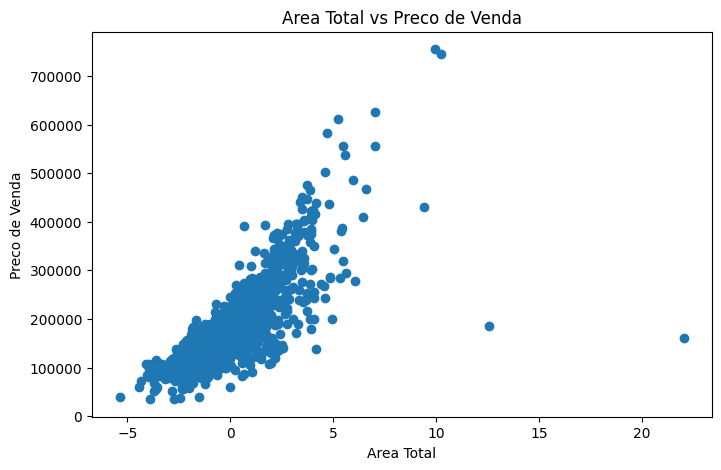

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(train_df["Area_Total_Construida"], train_df["Preco_Venda"])
plt.xlabel("Area Total")
plt.ylabel("Preco de Venda")
plt.title("Area Total vs Preco de Venda")
plt.show()

**Análise do Gráfico de Dispersão e Escala dos Dados:**

A partir da visualização inicial dos dados, é possível observar uma clara tendência linear positiva entre as duas variáveis: de modo geral, quanto maior a área da casa, maior tende a ser o seu valor de venda, o que fundamenta a escolha deste modelo.

**Mas por que a Área Total possui valores negativos no eixo X?**

Para facilitar o aprendizado do nosso modelo, nós aplicamos uma técnica de preparação de dados chamada **Padronização**. Em vez de usar os **pés quadrados** reais, nós transformamos os tamanhos em uma escala de "distância da média". Na prática, o gráfico deve ser lido assim:

* **O valor `0`:** Representa o tamanho exato de uma casa "na média" da nossa base de dados.
* **Valores positivos (+2, +4):** São as casas com área maior do que a média.
* **Valores negativos (-2, -4):** Representam as casas que são menores do que a média.

In [13]:
X = train_df[["Area_Total_Construida"]]
y = train_df["Preco_Venda"]

modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[31456.8]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area_Total_Construida']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.809e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [14]:
print(f"Intercepto: {modelo.intercept_:.2f}")
print(f"Coeficiente angular: {modelo.coef_[0]:.2f}")

Intercepto: 180921.20
Coeficiente angular: 31456.80


**Entendendo os valores**

**Intercepto**: O intercepto representa o valor projetado para o preço (y) quando a área (x) é igual a 0. Como aplicamos a padronização (StandardScaler), o valor 0 no eixo X corresponde exatamente ao tamanho de uma casa "na média" do nosso conjunto de dados. Portanto, o modelo aprendeu que o preço base estimado para uma casa de tamanho médio é de $ 180.921,19.

**Coeficiente**: O coeficiente define a inclinação da reta de regressão, indicando o quanto o preço sobe a cada unidade avançada no eixo X. Cda unidade não representa um pé quadrado individual, mas sim um desvio padrão. Isso significa que, para cada "passo" (desvio padrão) que a casa cresce além da área média, o modelo prevê um acréscimo de $ 31.456,79 no seu valor de venda.

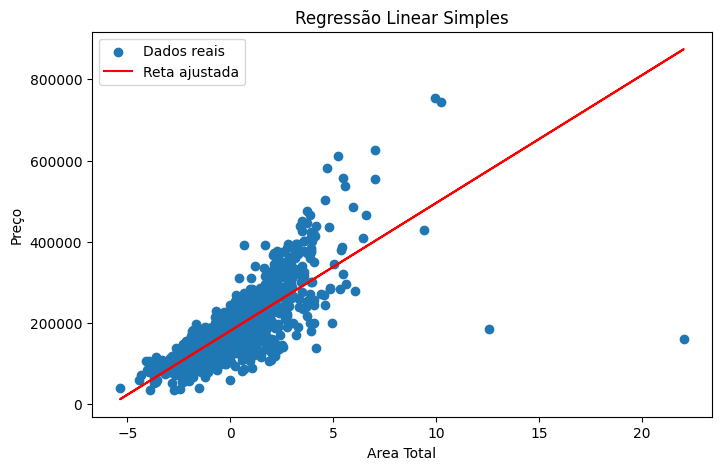

In [15]:
y_pred = modelo.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(train_df["Area_Total_Construida"], train_df["Preco_Venda"], label="Dados reais")
plt.plot(train_df["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")
plt.xlabel("Area Total")
plt.ylabel("Preço")
plt.title("Regressão Linear Simples")
plt.legend()
plt.show()

In [16]:
residuos = y - y_pred
train_df["Valor_Previsto"] = y_pred
train_df["Residuo"] = residuos

train_df

,Preco_Venda,Qualidade_Geral,Area_Total_Construida,Area_Habitavel_Acima_Solo,Qualidade_Externa,Qualidade_Cozinha,Qualidade_Porao,Capacidade_Carros_Garagem,Area_Garagem,Area_Total_Porao,Total_Banheiros,Area_Primeiro_Andar,Banheiros_Completos,Total_Comodos_Acima_Solo,Acabamento_Garagem,Tipo_Fundacao_PConc,Ano_Construcao_Garagem,Area_Alvenaria,Lareiras,Qualidade_Piscina,Qualidade_Aquecimento,Bairro_NridgHt,Idade_Imovel_Venda,Area_Acab_Porao1,Idade_Reforma_Venda,Classe_Imovel_60,Tipo_Venda_New,Tipo_Garagem_Detchd,Exposicao_Porao,Condicao_Venda_Partial,Fachada_Lote_Pes,Tipo_Fundacao_CBlock,Tipo_Garagem_Attchd,Tipo_Alvenaria_Stone,Bairro_NoRidge,Area_Deck_Madeira,Area_Segundo_Andar,Area_Varanda_Aberta,Revestimento_Externo2_VinylSd,Revestimento_Externo1_VinylSd,Valor_Previsto,Residuo
0,208500,0.651479,-0.090885,0.370333,1.052302,0.735994,0.617669,0.311725,0.351000,-0.459303,2.390813,-0.793434,0.789741,0.912210,0.225776,1.120968,0.992426,0.510015,-0.951226,NaN,0.891179,-0.235958,-0.912216,0.575425,-0.739891,1.970518,-0.301962,-0.600559,-0.643500,-0.305995,-0.208034,-0.876102,0.823505,-0.309994,-0.169981,-0.752176,1.161852,0.216503,1.377253,1.354604,178062.252857,30437.747143
1,181500,-0.071836,-0.071558,-0.482512,-0.689604,-0.771091,0.617669,0.311725,-0.060731,0.466465,1.563370,0.257140,0.789741,-0.318683,0.225776,-0.892086,-0.101543,-0.572835,0.600495,NaN,0.891179,-0.235958,-0.771172,1.171992,-0.184862,-0.507481,-0.301962,-0.600559,2.222025,-0.305995,0.409895,1.141420,0.823505,-0.309994,-0.169981,1.626195,-0.795163,-0.704483,-0.726083,-0.738223,178670.214137,2829.785863
2,223500,0.651479,0.248156,0.515013,1.052302,0.735994,0.617669,0.311725,0.631726,-0.313369,2.390813,-0.627826,0.789741,-0.318683,0.225776,1.120968,0.911391,0.322174,0.600495,NaN,0.891179,-0.235958,-0.845975,0.092907,-0.691437,1.970518,-0.301962,-0.600559,0.311675,-0.305995,-0.084449,-0.876102,0.823505,-0.309994,-0.169981,-0.752176,1.189351,-0.070361,1.377253,1.354604,188727.383669,34772.616331
3,140000,0.651479,-0.271782,0.383659,-0.689604,0.735994,-0.852135,1.650307,0.790804,-0.687324,-0.419572,-0.521734,-1.026041,0.296763,-1.004839,-0.892086,0.789839,-0.572835,0.600495,NaN,-0.151386,-0.235958,0.495977,-0.499274,-0.647357,-0.507481,-0.301962,1.665116,-0.643500,-0.305995,-0.414011,-0.876102,-1.214321,-0.309994,-0.169981,-0.752176,0.937276,-0.176048,-0.726083,-0.738223,172371.819510,-32371.819510
4,250000,1.374795,1.771946,1.299326,1.052302,0.735994,0.617669,1.650307,1.698485,0.199680,2.390813,-0.045611,0.789741,1.527656,0.225776,1.120968,0.870874,1.360826,0.600495,NaN,0.891179,-0.235958,-0.812854,0.463568,-0.594530,1.970518,-0.301962,-0.600559,1.266850,-0.305995,0.574676,-0.876102,0.823505,-0.309994,5.883006,0.780197,1.617877,0.563760,1.377253,1.354604,236660.933626,13339.066374
5,143000,-0.795151,-1.042932,-0.292145,-0.689604,-0.771091,0.617669,0.311725,0.032844,-0.596115,0.575031,-0.948691,-1.026041,-0.934130,-1.004839,-0.892086,0.587252,-0.572835,-0.951226,NaN,0.891179,-0.235958,0.172207,0.632450,0.400954,-0.507481,-0.301962,-0.600559,-0.643500,-0.305995,0.615871,-0.876102,0.823505,-0.309994,-0.169981,-0.432931,0.501875,-0.251539,1.377253,1.354604,148113.900684,-5113.900684
6,307000,1.374795,2.013106,0.339875,1.052302,0.735994,2.087474,0.311725,0.762732,1.433276,1.396210,1.374993,0.789741,0.296763,0.225776,1.120968,1.032943,0.454768,0.600495,NaN,0.891179,-0.235958,-1.698553,2.029558,-1.590014,-0.507481,-0.301962,-0.600559,1.266850,-0.305995,0.203918,-0.876102,0.823505,3.225872,-0.169981,1.283007,-0.795163,0.156111,1.377253,1.354604,244247.057407,62752.942593
7,200000,0.651479,1.426557,1.093729,-0.689604,-0.771091,0.617669,0.311725,0.051559,0.113032,2.390813,-0.143941,0.789741,0.296763,0.225776,-0.892086,-0.223095,0.753104,2.152216,NaN,0.891179,-0.235958,0.834622,0.910994,1.466931,1.970518,-0.301962,-0.600559,0.311675,-0.305995,NaN,1.141420,0.823505,3.225872,-0.169981,1.123385,1.457466,2.375537,-0.726083,-0.738223,225796.106879,-25796.106879
8,129900,0.651479,0.3238

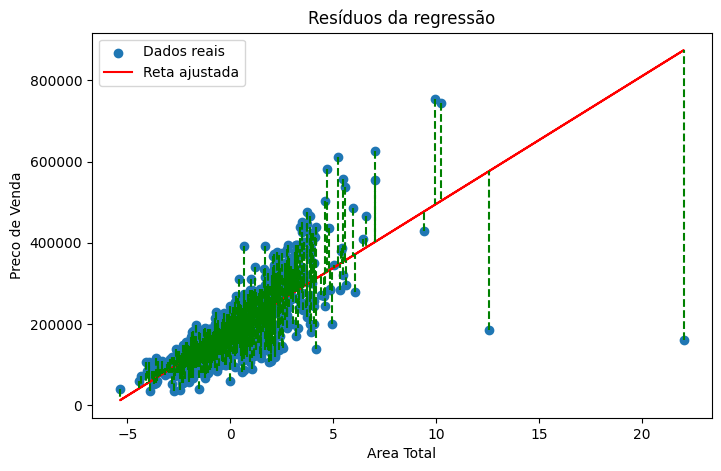

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["Area_Total_Construida"], train_df["Preco_Venda"], label="Dados reais")
plt.plot(train_df["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")

for i in range(len(train_df)):
    plt.plot(
        [train_df["Area_Total_Construida"][i], train_df["Area_Total_Construida"][i]],
        [train_df["Preco_Venda"][i], train_df["Valor_Previsto"][i]],
        linestyle="--", color="green"
    )

plt.xlabel("Area Total")
plt.ylabel("Preco de Venda")
plt.title("Resíduos da regressão")
plt.legend()
plt.show()

**Resíduos:**

No gráfico acima, adicionamos uma nova camada de informação: as linhas verdes tracejadas (Resíduos)

De forma simples, o resíduo representa o "erro" da nossa predição para cada casa individualmente. Ele é a diferença exata entre o que aconteceu na vida real e o que o modelo calculou. Visualmente, temos a seguinte composição:

* **O Ponto Azul**: É a realidade. Representa o preço real pelo qual a casa foi vendida.
* **A Reta Vermelha**: É a previsão. Representa o preço que o nosso modelo estimou com base no tamanho da casa.
* **A Linha Verde**: É a distância entre os dois. Quanto mais longa for essa linha, maior foi o erro do modelo em dólares para aquele imóvel específico. Se o ponto azul estiver exatamente em cima da reta vermelha, significa que o modelo cravou o preço.

Analisar os resíduos visualmente é essencial para atestar a qualidade da Regressão Linear. O nosso objetivo não é ter zero erros, mas sim garantir que essas linhas verdes sejam as mais curtas possíveis e que estejam distribuídas de forma equilibrada. 

In [26]:
r2 = r2_score(train_df["Preco_Venda"], y_pred)
mae = mean_absolute_error(train_df["Preco_Venda"], y_pred)

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): $ {mae:.2f}")

Coeficiente de Determinação (R²): 0.6095
Erro Absoluto Médio (MAE): $ 32113.74


## 3.2 Classificação

In [ ]:
X = train_df[["Area_Total_Construida"]]
y = train_df["Preco_Venda"]

mediana_preco = train_df["Preco_Venda"].median()
y_binario = (train_df["Preco_Venda"] > mediana_preco).astype(int)

modelo = GaussianNB()
modelo.fit(X, y_binario)

In [ ]:
entrada = train_df[["Area_Total_Construida"]].head(10)# testar com as primeiras n casas, nesse caso 10

probs = modelo.predict_proba(entrada)

resultado = pd.DataFrame(probs, columns=["Preço Baixo (0)", "Preço Alto (1)"])
resultado.index = [f"Casa (Linha {i})" for i in entrada.index]

display((resultado * 100).round(2).astype(str) + "%")

# 4. Aprendizagem Não Supervisionada

### Nota Técnica: A Interpretação dos Eixos Normalizados (-5, 0, 5)

Ao observar alguns dos gráficos de dispersão, é possível notar que os eixos X apresentam escalas com valores negativos e próximos a zero (ex: -5, 0, 5), em vez das medidas originais em pés quadrados.

Isso é um reflexo visual da **Padronização dos Dados**, uma etapa obrigatória antes de aplicar os algoritmos baseados em distância como o K-Means e o LOF.

Na prática, **O Ponto Zero (0)** representa a média exata daquela característica em todo o conjunto de dados.  
Quanto aos **Valores Positivos e Negativos**, os números representam o *Desvio Padrão* em relação à média. Portanto, um valor sendo -2 no eixo de Área indica uma casa consideravelmente menor que a média da cidade, enquanto um valor de +5 indica uma propriedade com dimensões muito superiores ao padrão local.

## 4.1 Clusterização

## 4.1.1 Implementação do Método do Cotovelo

In [ ]:
X = train_df.drop(['Preco_Venda'], axis=1)

X = X.fillna(0)

inercia = []

valores_k = range(1,11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(X)
    inercia.append(kmeans_teste.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Espalhamento dos dados)')
plt.xticks(valores_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Qual a utilidade do método do Cotovelo para definição dos Clusters?**

O Método do Cotovelo é utilizado para nos permitir encontrar a quantidade ideal de grupos, identificando o ponto exato onde o ganho em reduzir a variância (inércia) passa a ser insignificante, evitando a criação de grupos desnecessários. Diante disso, optamos por executar o método previamente ao treinamento do modelo.

## 4.1.2 Algoritmo de Clusterização: K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

train_df['cluster'] = kmeans.predict(X)

eixo_x = train_df['Area_Total_Construida']
eixo_y = train_df['Preco_Venda']

colors = {0: 'red', 1: 'blue', 2: 'green'}

train_df['color'] = train_df['cluster'].map(colors)

plt.figure(figsize=(10, 6))
plt.scatter(eixo_x, eixo_y, color=train_df['color'], alpha=0.6)
plt.title('Casas Clusterizadas')
plt.xlabel('Área Total Construída (GrLivArea)')
plt.ylabel('Preço de Venda')
plt.show()

**Por que escolhemos o K-Means?**

No mercado imobiliário, os imóveis não se distribuem de forma totalmente caótica; eles se organizam naturalmente em nichos de consumo. Escolhemos o K-Means porque ele possui excelente performance para processar e cruzar dezenas de características estruturais simultaneamente.

**A remoção da variável alvo ('Preco_Venda')**

A coluna 'Preco_Venda' foi intencionalmente removida para que o conjunto de dados de treinamento não fosse totalmente dominado pela sua magnitude, fazendo com que a IA criasse grupos baseados puramente em faixas de preço. Portanto, o modelo considera características físicas das casas, o que altera a forma como ele organiza os clusters.

## 4.1.3 Perfilagem dos Clusters

In [ ]:
colunas_perfil = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt', 'SalePrice']
df_perfil = train_csv[colunas_perfil].copy()

df_perfil['Cluster'] = train_df['cluster']

resumo_clusters = df_perfil.groupby('Cluster').mean().round(0)

resumo_clusters = resumo_clusters.rename(columns={
    'GrLivArea': 'Média de Área (Pés²)',
    'OverallQual': 'Qualidade Média (1-10)',
    'GarageCars': 'Média de Vagas Garagem',
    'YearBuilt': 'Ano Médio de Construção',
    'SalePrice': 'Preço Médio de Venda ($)'
})

display(resumo_clusters)

**Por que a exibição da perfilagem?**

A perfilagem foi utilizada como forma de tradução do gráfico apresentado acima, visto que ele exibe apenas as cores dos clusters e não o que são de forma intrínseca. Portanto, com essa pequena tabela podemos ver as médias referentes a cada cluster.

**Cor dos clusters:**  
Cluster 0: Vermelho  
Cluster 1: Azul  
Cluster 2: Verde

## 4.2 Redução de dimensionalidade (PCA)

In [ ]:
colunas_para_remover = ['Preco_Venda', 'cluster', 'color']
X_pca_input = train_df.drop(colunas_para_remover, axis=1, errors='ignore')

X_pca_input = X_pca_input.fillna(0)

pca = PCA(n_components=2)

pca.fit(X_pca_input)
X_pca = pca.transform(X_pca_input)

centroides_originais = kmeans.cluster_centers_

centroides_2d = pca.transform(centroides_originais)

plt.figure(figsize=(10, 6))

nomes_clusters = {0: 'Grupo Popular', 1: 'Grupo Padrão', 2: 'Grupo Premium'}
cores = {0: 'red', 1: 'blue', 2: 'green'}

for cluster_id in [0, 1, 2]:
    idx = train_df['cluster'] == cluster_id
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                color=cores[cluster_id], 
                label=nomes_clusters[cluster_id], 
                alpha=0.6)

plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], 
            marker='X', s=350, color='gold', edgecolor='black', 
            linewidth=2, label='Centroides (Média do Grupo)')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Redução de Dimensionalidade: PCA (Visualizando os 3 Clusters)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Por que utilizamos a Redução de Dimensionalidade (PCA)?**

O algoritmo K-Means analisou quase 40 características arquitetônicas simultaneamente. Porém, visualmente é impossível plotar um gráfico com 40 eixos cruzados para comprovar se os grupos realmente ficaram bem separados.  
Para resolver essa limitação visual, aplicamos a Redução de Dimensionalidade através do PCA, que basicamente atua como um compressor, transformando o que seriam 40 eixos em apenas 2, sendo Componente Principal 1 e 2. Ele faz isso calculando as direções de maior variância dos dados, garantindo que a perda de informação seja a menor possível durante o achatamento.

## 4.3 Apriori

In [ ]:
df_casas = pd.DataFrame()


df_casas['Ar_Condicionado'] = train_csv['CentralAir'] == 'Y'
df_casas['Lareira'] = train_csv['Fireplaces'] > 0
df_casas['Garagem_dupla_ou_mais'] = train_csv['GarageCars'] >= 2
df_casas['Alta_Qualidade_Geral'] = train_csv['OverallQual'] >=7
df_casas['Porao'] = train_csv['TotalBsmtSF'] > 0
df_casas['Casa_recente_pos_2000'] = train_csv['YearBuilt'] >= 2000

itens_frequentes = apriori(df_casas, min_support=0.3, use_colnames=True)

regras = association_rules(itens_frequentes, metric="confidence", min_threshold=0.7)
regras = regras.sort_values(by='lift', ascending=False)

regras_pt = regras.rename(columns={
    'antecedents': 'Se (Antecedente)',
    'consequents': 'Então (Consequente)',
    'support': 'Suporte (Frequência %)',
    'confidence': 'Confiança (Probabilidade %)',
    'lift': 'Lift (Força da Regra)'
})

colunas_exibir = ['Se (Antecedente)', 'Então (Consequente)', 'Suporte (Frequência %)', 'Confiança (Probabilidade %)', 'Lift (Força da Regra)']

display(regras_pt[colunas_exibir].head(10))

**Por que utilizamos o Apriori?**
  
O algoritmo Apriori permite a descoberta de regras de associação, ou seja, ele nos permite validar regras de associação entre as variáveis usadas pelo modelo.

O **Suporte (Frequência)** apresenta a frequência de ocorrência desses casos em cima dos dados gerais.  
A **Confiança (Probabilidade)** apresenta a probabilidade de a regra ocorrer.  
E, por fim, o **Lift**, que representa a força da regra, provando a não mera coincidência, considerando que isso se aplica a lifts maiores que 1.0.

## 4.4 Local Outlier Factor

In [ ]:
colunas_para_remover = ['Preco_Venda', 'cluster', 'color', 'cluster_3', 'color_3']
X_outlier = train_df.drop(colunas_para_remover, axis=1, errors='ignore')

X_outlier = X_outlier.fillna(0)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)


previsoes_outliers = lof.fit_predict(X_outlier)

train_df['Outlier'] = previsoes_outliers

casas_outliers = train_df[train_df['Outlier'] == -1]

plt.figure(figsize=(10, 6))## 4.2 Reducao de dimensionalidade (PCA)

inliers_idx = previsoes_outliers == 1
plt.scatter(X_pca[inliers_idx, 0], X_pca[inliers_idx, 1], color='lightgray', alpha=0.5, label='Casas Normais')

outliers_idx = previsoes_outliers == -1
plt.scatter(X_pca[outliers_idx, 0], X_pca[outliers_idx, 1], color='red', edgecolor='black', label='Outliers (LOF)')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Identificação de Outliers com LOF (Projetado no PCA)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Por que utilizamos o Local Outlier Factor (LOF)?**

O LOF é um modelo de detecção de anomalias baseado em densidade. Basicamente, ele mede a distância de uma casa para os seus 20 vizinhos estruturais mais próximos. Se a casa estiver muito mais isolada do que a média dos seus vizinhos, ela é classificada como uma anomalia (-1).  

Na prática, esse modelo nos permite visualizar casas que possuem configurações raras, ou seja, destoantes das demais casas que estão na cor cinza.